In [ ]:
%matplotlib widget
from Pyriod import Pyriod
import lightkurve as lk

search_result = lk.search_lightcurve('KIC 5559631', mission = 'KEPLER')
lc_collection = search_result[4].download_all()
for curve in lc_collection:
    curve = curve.normalize()
    curve = curve.remove_nans()
    
lc_stitched = lc_collection.stitch(
    corrector_func=lambda x: x.remove_nans().normalize().flatten().remove_outliers(
        sigma = 3))
print("Data pruned and stitched!")
search_result = 0
lc_collection = 0


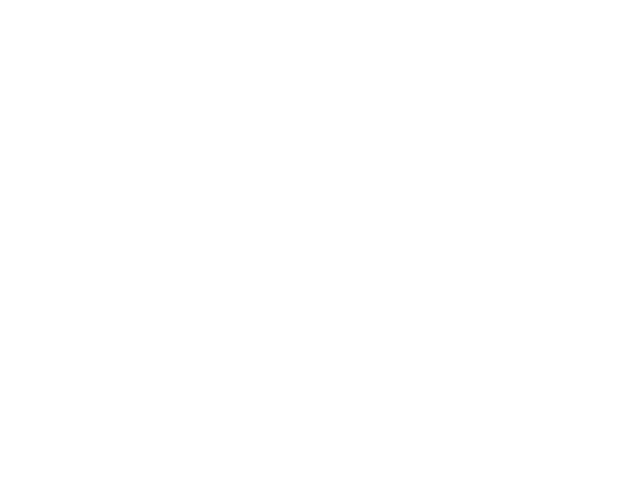

In [4]:
pyriod = Pyriod(lc_stitched)
pyriod.Pyriod()

In [ ]:
import pandas as pd

dataframe = pd.DataFrame({
    'time': pyriod.lc["time"],
    'flux': pyriod.lc["flux"],
    'residual': pyriod.lc["resid"],
    'model': pyriod.lc["model"],
})

dataframe.to_csv('residuals_Quarters_4.csv', index = False)